### Libraries

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt
import geotherm_calculator as gc
import planetary_grid_reader as pgr
import habitability_calculator as hc

from astropy import constants as const
from scipy.signal import savgol_filter


### Constants

In [2]:
Gpa = 1e9
Mpa = 1e6
km = 1e3
to = 1.386e9 #Terrestrial Oceans volume in km3

Me = const.M_earth.value # Earth mass (kg) 
Re = const.R_earth.value # Earth radius (m) 

### Plots Config

In [7]:
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.2,
})


### HC Composition

In [3]:
mineral_objects = gc.get_mineral_objects()
rocks = gc.prepare_rocks_dict(mineral_objects=mineral_objects)
upper = rocks['upper']

### Basal Flux Extraction

In [4]:
planetary_grid_path = "PlanetaryGrid"
target_folder = "CMF_0.30-IMF_0.00"
planet = 'M1.00'
folder_path = os.path.join(planetary_grid_path, target_folder)

if not os.path.isdir(folder_path):
    print(f"Error: Folder '{folder_path}' not found.")
else:
    files = sorted(os.listdir(folder_path))
    tevol_files = [f for f in files if f.startswith(planet) and f.endswith('TEVOL.dat')]
    if not tevol_files:
        print(f"No TEVOL.dat files found in {folder_path}")
    else:
        for tfile in tevol_files:
            path_tevol = os.path.join(folder_path, tfile)
            data_tevol = pgr.read_tevol_dat(path_tevol)
            ts = np.array(data_tevol['#t']) /1e9
            qm = np.array(data_tevol['Qm']) 
            qss = qm / (4*np.pi*Re**2) 

### Function: Temporal evolution of subsurface habitability

In [ ]:
def habitability_vs_time_geological(rocks,
                                R_planet,
                                M_planet, Tsurf,
                                qss,
                                ts,  
                                composition=None,
                                information=True):
    
    boundaries = gc.scale_layer_boundaries(R_planet=R_planet)
    t_geological =ts


    df_geothermic_evolution = gc.calculate_geotherm_evolution(
        rocks=rocks,
        R_planet=R_planet,
        M_total=M_planet,
        z_max=10e3,
        composition=composition,
        boundaries=boundaries,
        dz=25.0,
        qss=qss,
        T_top=Tsurf,
        t_Ga=t_geological,
        As_type='Hasterok')
    

    t_Ga = df_geothermic_evolution['t_Ga']
    q_s = df_geothermic_evolution['q_s']
    profiles = df_geothermic_evolution['profiles']

    # Listas para almacenar resultados
    water_thickness_time = []
    habitable_thickness_time = []
    water_depth_top_time = []
    water_depth_bottom_time = []
    habitable_depth_top_time = []
    habitable_depth_bottom_time = []

    print("=" * 80)
    print("CALCULANDO CapaS DE HABITABILIDAD EN EL TIEMPO GEOLÓGICO")
    print("=" * 80)

    # Procesar cada perfil geotérmico en el tiempo
    for i, (t, q, df_profile) in enumerate(zip(t_Ga, q_s, profiles)):
        print(f"\nTiempo: {t:.2f} Ga | Flujo de calor: {q*1000:.1f} mW/m²")
        
        # Calcular Capas de habitabilidad
        liquid_data = hc.find_liquid_zone(df_profile, information=False)
        habitable_data = hc.find_habitable_zone(liquid_data['indices'], df_profile, information=False)
        
        # Almacenar datos de Capa de aguabilidad
        if liquid_data['liquid_zone'] is not None:
            water_top = liquid_data['liquid_zone'][0] / 1000  # km
            water_bottom = liquid_data['liquid_zone'][-1] / 1000  # km
            water_thick = water_bottom - water_top
            
            water_depth_top_time.append(water_top)
            water_depth_bottom_time.append(water_bottom)
            water_thickness_time.append(water_thick)
            if information:
                print(f"  💧 Capa de Aguabilidad: {water_top:.2f} - {water_bottom:.2f} km (espesor: {water_thick:.2f} km)")
        else:
            water_depth_top_time.append(np.nan)
            water_depth_bottom_time.append(np.nan)
            water_thickness_time.append(0)
            if information:
                print(f"  💧 Capa de Aguabilidad: No existe")
        
        # Almacenar datos de Capa habitable
        if habitable_data['habitable_zone'] is not None:
            hab_top = habitable_data['habitable_zone'][0] / 1000  # km
            hab_bottom = habitable_data['habitable_zone'][-1] / 1000  # km
            hab_thick = hab_bottom - hab_top
            
            habitable_depth_top_time.append(hab_top)
            habitable_depth_bottom_time.append(hab_bottom)
            habitable_thickness_time.append(hab_thick)

            if information:
                print(f"  🦠 Capa Habitable: {hab_top:.2f} - {hab_bottom:.2f} km (espesor: {hab_thick:.2f} km)")
        else:
            habitable_depth_top_time.append(np.nan)
            habitable_depth_bottom_time.append(np.nan)
            habitable_thickness_time.append(0)
            if information:
                print(f"  🦠 Capa Habitable: No existe")

    # Convertir a arrays numpy
    water_thickness_time = np.array(water_thickness_time)
    habitable_thickness_time = np.array(habitable_thickness_time)
    water_depth_top_time = np.array(water_depth_top_time)
    water_depth_bottom_time = np.array(water_depth_bottom_time)
    habitable_depth_top_time = np.array(habitable_depth_top_time)
    habitable_depth_bottom_time = np.array(habitable_depth_bottom_time)
    
    data_time = {
                't_Ga': t_Ga,
                'q_s': q_s,
                'water_thickness_time': water_thickness_time,
                'habitable_thickness_time': habitable_thickness_time,
                'water_depth_top_time': water_depth_top_time,
                'water_depth_bottom_time': water_depth_bottom_time,
                'habitable_depth_top_time': habitable_depth_top_time,
                'habitable_depth_bottom_time': habitable_depth_bottom_time,
                'attributes': {
                    'R_planet': R_planet,
                    'M_planet': M_planet,
                    'composition': composition,
                }
        }
    
    return data_time

In [7]:
Tsurf = hc.T_eq(1)
data_time_1ua = habitability_vs_time_geological(rocks=rocks,
                                            R_planet=Re,
                                            M_planet=Me,
                                            Tsurf=Tsurf,
                                            qss = qss,
                                            ts=ts,
                                            information=False)

CALCULANDO EVOLUCIÓN TEMPORAL DEL GRADIENTE GEOTÉRMICO
Modelo: Turcotte & Schubert (2014)
Número de tiempos: 352
R_planet = 6.378 x 10^6 m
M_total = 5.972 x 10^24 kg
  t =  0.000 Ga | q_s = 3081.8 mW/m² | dT/dz = 1724.5 K/km
  t =  0.010 Ga | q_s = 2661.1 mW/m² | dT/dz = 1450.0 K/km
  t =  0.020 Ga | q_s = 2330.5 mW/m² | dT/dz = 1241.0 K/km
  t =  0.030 Ga | q_s = 2065.9 mW/m² | dT/dz = 1074.1 K/km
  t =  0.040 Ga | q_s = 1850.5 mW/m² | dT/dz = 937.5 K/km
  t =  0.050 Ga | q_s = 1672.7 mW/m² | dT/dz = 825.7 K/km
  t =  0.060 Ga | q_s = 1524.0 mW/m² | dT/dz = 734.2 K/km
  t =  0.070 Ga | q_s = 1398.2 mW/m² | dT/dz = 658.9 K/km
  t =  0.080 Ga | q_s = 1290.8 mW/m² | dT/dz = 596.5 K/km
  t =  0.090 Ga | q_s = 1198.2 mW/m² | dT/dz = 544.2 K/km
  t =  0.100 Ga | q_s = 1117.7 mW/m² | dT/dz = 499.8 K/km
  t =  0.110 Ga | q_s = 1047.2 mW/m² | dT/dz = 461.9 K/km
  t =  0.120 Ga | q_s =  985.1 mW/m² | dT/dz = 429.1 K/km
  t =  0.130 Ga | q_s =  930.0 mW/m² | dT/dz = 400.6 K/km
  t =  0.140 Ga | 

In [8]:
Tsurf = hc.T_eq(1.5)
data_time_15ua = habitability_vs_time_geological(rocks=rocks,
                                            R_planet=Re,
                                            M_planet=Me,
                                            Tsurf=Tsurf,
                                            qss = qss,
                                            ts=ts,
                                            information=False)

CALCULANDO EVOLUCIÓN TEMPORAL DEL GRADIENTE GEOTÉRMICO
Modelo: Turcotte & Schubert (2014)
Número de tiempos: 352
R_planet = 6.378 x 10^6 m
M_total = 5.972 x 10^24 kg
  t =  0.000 Ga | q_s = 3081.8 mW/m² | dT/dz = 1679.2 K/km
  t =  0.010 Ga | q_s = 2661.1 mW/m² | dT/dz = 1408.8 K/km
  t =  0.020 Ga | q_s = 2330.5 mW/m² | dT/dz = 1200.4 K/km
  t =  0.030 Ga | q_s = 2065.9 mW/m² | dT/dz = 1032.7 K/km
  t =  0.040 Ga | q_s = 1850.5 mW/m² | dT/dz = 896.7 K/km
  t =  0.050 Ga | q_s = 1672.7 mW/m² | dT/dz = 786.9 K/km
  t =  0.060 Ga | q_s = 1524.0 mW/m² | dT/dz = 698.2 K/km
  t =  0.070 Ga | q_s = 1398.2 mW/m² | dT/dz = 625.7 K/km
  t =  0.080 Ga | q_s = 1290.8 mW/m² | dT/dz = 565.7 K/km
  t =  0.090 Ga | q_s = 1198.2 mW/m² | dT/dz = 515.6 K/km
  t =  0.100 Ga | q_s = 1117.7 mW/m² | dT/dz = 473.2 K/km
  t =  0.110 Ga | q_s = 1047.2 mW/m² | dT/dz = 437.0 K/km
  t =  0.120 Ga | q_s =  985.1 mW/m² | dT/dz = 405.8 K/km
  t =  0.130 Ga | q_s =  930.0 mW/m² | dT/dz = 378.7 K/km
  t =  0.140 Ga | 

In [9]:
np.save("data_time_1ua.npy", data_time_1ua)
np.save("data_time_15ua.npy", data_time_15ua)

### Data Smooth

In [ ]:
t_Ga1 = data_time_1ua['t_Ga']
water_thickness_time1 = data_time_1ua['water_thickness_time']
habitable_thickness_time1 = data_time_1ua['habitable_thickness_time']
water_depth_top_time1 = data_time_1ua['water_depth_top_time']
water_depth_bottom_time1 = data_time_1ua['water_depth_bottom_time']
habitable_depth_top_time1 = data_time_1ua['habitable_depth_top_time']
habitable_depth_bottom_time1 = data_time_1ua['habitable_depth_bottom_time']
attributes = data_time_1ua['attributes']

water_thickness_time15 = data_time_15ua['water_thickness_time']
habitable_thickness_time15 = data_time_15ua['habitable_thickness_time']
water_depth_top_time15 = data_time_15ua['water_depth_top_time']
water_depth_bottom_time15 = data_time_15ua['water_depth_bottom_time']
habitable_depth_top_time15 = data_time_15ua['habitable_depth_top_time']
habitable_depth_bottom_time15 = data_time_15ua['habitable_depth_bottom_time']

### Plot Temporal evolution of subsurface habitability

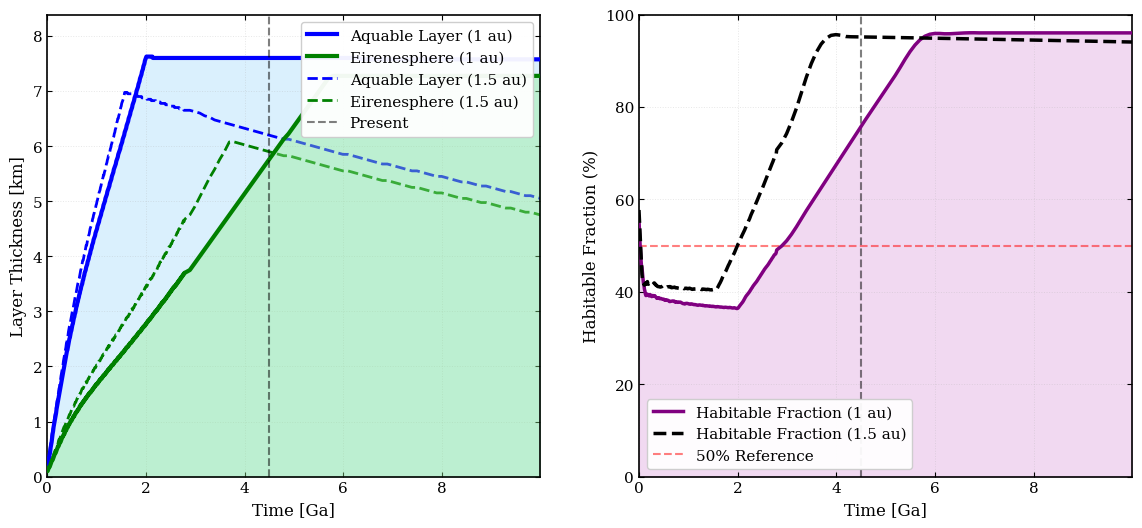

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

ax1 = axes[0]
ax1.plot(t_Ga1, water_thickness_time1, 'b-', linewidth=3,label='Aquable Layer (1 au)', zorder=3)
ax1.plot(t_Ga1, habitable_thickness_time1, 'g-', linewidth=3, label='Eirenesphere (1 au)', zorder=3)
ax1.plot(t_Ga1, water_thickness_time15, 'b--', linewidth=2, label='Aquable Layer (1.5 au)', zorder=2)
ax1.plot(t_Ga1, habitable_thickness_time15, 'g--', linewidth=2, label='Eirenesphere (1.5 au)', zorder=2)
ax1.fill_between(t_Ga1, 0, water_thickness_time1, color='lightskyblue', alpha=0.3, zorder=1)
ax1.fill_between(t_Ga1, 0, habitable_thickness_time1, color='lightgreen', alpha=0.4, zorder=2)
ax1.axvline(4.5, color='k', linestyle='--', alpha=0.5, label='Present', zorder=4)

ax1.set_xlabel('Time [Gyr]')
ax1.set_ylabel('Layer Thickness [km]')
ax1.legend(loc='upper right', framealpha=0.95)
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
ax1.set_xlim(0, max(t_Ga1))
ax1.set_ylim(0, max(water_thickness_time1) * 1.1)


ax2 = axes[1]
# Calcular fracción habitable (evitar división por cero)
frac_habitable = np.where(
    water_thickness_time1 > 0,
    (habitable_thickness_time1 / water_thickness_time1) * 100,
    0
)

frac_habitable_15ua = np.where(
    water_thickness_time15 > 0,
    (habitable_thickness_time15 / water_thickness_time15) * 100,
    0
)

# Suavizado Savitzky-Golay
frac_habitable_smooth = savgol_filter(
    frac_habitable,
    window_length=11,   # debe ser impar
    polyorder=3
)

frac_habitable_15ua_smooth = savgol_filter(
    frac_habitable_15ua,
    window_length=11,   # debe ser impar
    polyorder=3
)

ax2.plot(
    t_Ga1,
    frac_habitable_smooth,
    color='purple',
    linewidth=2.5,
    label='Habitable Fraction (1 au)',
    zorder=3
)

ax2.plot(
    t_Ga1,
    frac_habitable_15ua_smooth,
    color='black',
    linestyle='--',
    linewidth=2.5,
    label='Habitable Fraction (1.5 au)',
    zorder=3
)

ax2.fill_between(
    t_Ga1,
    0,
    frac_habitable_smooth,
    color='plum',
    alpha=0.4,
    zorder=1
)
ax2.axhline(50, color='red', linestyle='--', alpha=0.5, 
                label='50% Reference', zorder=2)


ax2.set_xlabel('Time [Ga]')
ax2.set_ylabel('Habitable Fraction (%)')
ax2.legend(loc='best',framealpha=0.95)
ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
ax2.set_xlim(0, max(t_Ga1))
ax2.set_ylim(0, 100)

ax2.axvline(4.5, color='k', linestyle='--', alpha=0.5)